## 1. Setup & Environment
Importing required libraries, setting up metric tools, and assigning computations to the GPU for faster training.

In [1]:
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Environment ready. Computations will run on: {device}")

Environment ready. Computations will run on: cuda:0


## 2. Data Rebalancing (Run Once)
Moves a designated percentage (15%) of the training images into the validation folder. This ensures the validation set is large enough to provide meaningful feedback during training. *Note: The function call is commented out so it isn't accidentally run multiple times.*

In [2]:
def rebalance_train_val(train_dir='../data/train', val_dir='../data/val', split_ratio=0.15):
    """Moves a percentage of training images to the validation set."""
    for cls in ['NORMAL', 'PNEUMONIA']:
        source = os.path.join(train_dir, cls)
        dest = os.path.join(val_dir, cls)
        
        files = os.listdir(source)
        num_to_move = int(len(files) * split_ratio)
        to_move = random.sample(files, num_to_move)
        
        for f in to_move:
            shutil.move(os.path.join(source, f), os.path.join(dest, f))
    print("Rebalancing complete.")

# Uncomment the line below ONLY if raw data folders were reset
# rebalance_train_val()

## 3. Data Pipeline & Augmentation
Loading the images and applying transformations. The training set receives random flips, rotations, and color adjustments to prevent overfitting. The validation and test sets are only resized and normalized.

In [3]:
data_dir = '../data'

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.1), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) 
                  for x in ['train', 'val', 'test']}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x == 'train')) 
               for x in ['train', 'val', 'test']}

print(f"Train samples: {len(image_datasets['train'])} | Val samples: {len(image_datasets['val'])} | Test samples: {len(image_datasets['test'])}")

Train samples: 3769 | Val samples: 1463 | Test samples: 624


## 4. Data Visualization
Fetches a single batch of augmented training data and visualizes it. This un-normalizes the tensors back into displayable images, allowing us to verify that our data loaders and image transformations (like flips and color jitter) are working correctly before feeding them into the model.

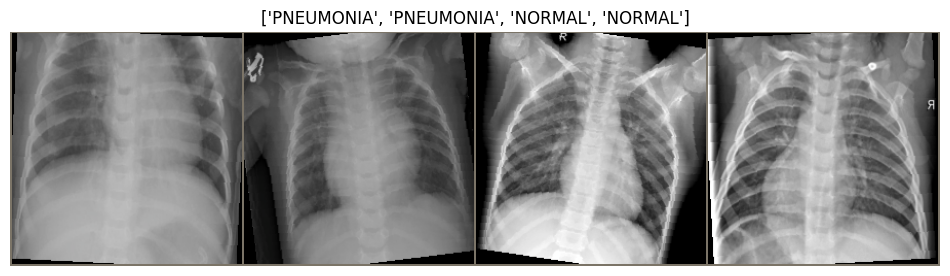

In [4]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    
    plt.figure(figsize=(12, 4))
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.pause(0.001)

# Grab a single batch and display
class_names = image_datasets['train'].classes
inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs[:4]) 
imshow(out, title=[class_names[x] for x in classes[:4]])

## 5. Model Initialization
Loading a pre-trained ResNet50 model and unfreezing all layers for fine-tuning. We replace the final layer for our 2 classes. Crucially, we weight the 'Pneumonia' class heavier in the loss function to minimize dangerous False Negatives, and add a learning rate scheduler.

In [5]:
model = models.resnet50(weights='IMAGENET1K_V1')
model.fc = nn.Linear(model.fc.in_features, 2) 

for param in model.parameters():
    param.requires_grad = True
model = model.to(device)

# Weight Pneumonia (index 1) higher to penalize False Negatives
weights = torch.tensor([1.0, 3.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Drops the learning rate by 10% every 3 epochs for smoother convergence
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

print("Fine-tuning model, loss, optimizer, and scheduler initialized.")

Fine-tuning model, loss, optimizer, and scheduler initialized.


## 6. Training Loop
Iterating through the data for multiple epochs. The model learns on the training set and evaluates its progress on the validation set. The scheduler steps down the learning rate automatically.

In [6]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=6):
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs} | {"-" * 20}')

        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])
            print(f'{phase.capitalize():<5} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print()
    return model

model = train_model(model, criterion, optimizer, scheduler, num_epochs=6)
os.makedirs('../models', exist_ok=True)
torch.save(model.state_dict(), '../models/pneumonia_resnet50_finetuned_v2.pth')

Epoch 1/6 | --------------------
Train Loss: 0.0927 Acc: 0.9491
Val   Loss: 0.0535 Acc: 0.9761

Epoch 2/6 | --------------------
Train Loss: 0.0480 Acc: 0.9682
Val   Loss: 0.0743 Acc: 0.9733

Epoch 3/6 | --------------------
Train Loss: 0.0347 Acc: 0.9782
Val   Loss: 0.0456 Acc: 0.9822

Epoch 4/6 | --------------------
Train Loss: 0.0189 Acc: 0.9883
Val   Loss: 0.0401 Acc: 0.9856

Epoch 5/6 | --------------------
Train Loss: 0.0182 Acc: 0.9894
Val   Loss: 0.0372 Acc: 0.9856

Epoch 6/6 | --------------------
Train Loss: 0.0160 Acc: 0.9907
Val   Loss: 0.0358 Acc: 0.9850



## 7. Final Evaluation & Confusion Matrix
Testing the model on unseen data. We generate a Confusion Matrix to explicitly track False Positives and False Negatives, ensuring our model prioritizes patient safety.

In [7]:
model.eval() 
all_preds, all_labels = [], []

print(f"Evaluating {len(image_datasets['test'])} test images...")

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate Advanced Metrics
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(f"True Normal (TN): {cm[0][0]}  | False Positive (FP): {cm[0][1]}")
print(f"False Negative (FN): {cm[1][0]} | True Pneumonia (TP): {cm[1][1]}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Normal', 'Pneumonia']))

Evaluating 624 test images...

Confusion Matrix:
True Normal (TN): 137  | False Positive (FP): 97
False Negative (FN): 0 | True Pneumonia (TP): 390

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.59      0.74       234
   Pneumonia       0.80      1.00      0.89       390

    accuracy                           0.84       624
   macro avg       0.90      0.79      0.81       624
weighted avg       0.88      0.84      0.83       624



## 8. Inference Script
A standalone function to test the fine-tuned model on new, raw X-ray images. It rebuilds the architecture, loads the saved weights safely in evaluation mode, applies the required image transformations, and outputs a human-readable diagnosis with confidence probabilities.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image

# 1. Set Device and Class Names
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
classes = ['NORMAL', 'PNEUMONIA']

# 2. Rebuild the Model Architecture and Load Your Saved Weights
model = models.resnet50(weights=None) # We don't need ImageNet weights anymore
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load('../models/pneumonia_resnet50_finetuned_v2.pth', weights_only=True))
model = model.to(device)
model.eval() # Set to evaluation mode

# 3. Define the exact same transforms used for the test set
inference_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_xray(image_path):
    """Takes an image path, runs it through the model, and prints the diagnosis."""
    # Open image and convert to RGB (some X-rays are grayscale)
    image = Image.open(image_path).convert('RGB')
    
    # Apply transforms and add a batch dimension (C, H, W) -> (1, C, H, W)
    input_tensor = inference_transforms(image).unsqueeze(0).to(device)
    
    # Run the model
    with torch.no_grad():
        output = model(input_tensor)
        
        # Convert raw output logits to percentages using Softmax
        probabilities = F.softmax(output, dim=1)[0]
        
        # Get the predicted class index
        _, predicted_idx = torch.max(output, 1)
        predicted_idx = predicted_idx.item()
        
    diagnosis = classes[predicted_idx]
    confidence = probabilities[predicted_idx].item() * 100
    
    print(f"--- Analysis Complete ---")
    print(f"Diagnosis: {diagnosis}")
    print(f"Confidence: {confidence:.2f}%")
    print(f"(Normal Probability: {probabilities[0].item()*100:.2f}% | Pneumonia Probability: {probabilities[1].item()*100:.2f}%)")

# ==========================================
# Testing. Provide a path to a raw image:
predict_xray('../data/test/PNEUMONIA/person30_virus_69.jpeg')
# ==========================================

--- Analysis Complete ---
Diagnosis: PNEUMONIA
Confidence: 99.71%
(Normal Probability: 0.29% | Pneumonia Probability: 99.71%)
